# 📊 VISUAL 1 — BENCHMARKING PARA TODOS
## *O que é detectar anomalias acústicas? Por que importa? Quem vence?*

---

> **Este notebook não tem código difícil.** Ele foi feito para qualquer pessoa entender o projeto do início ao fim, com visuais simples e analogias do dia a dia.

---

## 🏭 O PROBLEMA EM UMA FRASE

> *"Máquinas de fábrica quebram. Quando elas quebram sem aviso, custam milhões. E se um computador pudesse ouvir a máquina e dizer: 'esta vai quebrar em breve'?"*

---


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'text.color': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.edgecolor': '#30363d',
    'grid.color': '#30363d',
    'font.family': 'DejaVu Sans'
})
print('Pronto para entender tudo!')

Pronto para entender tudo!


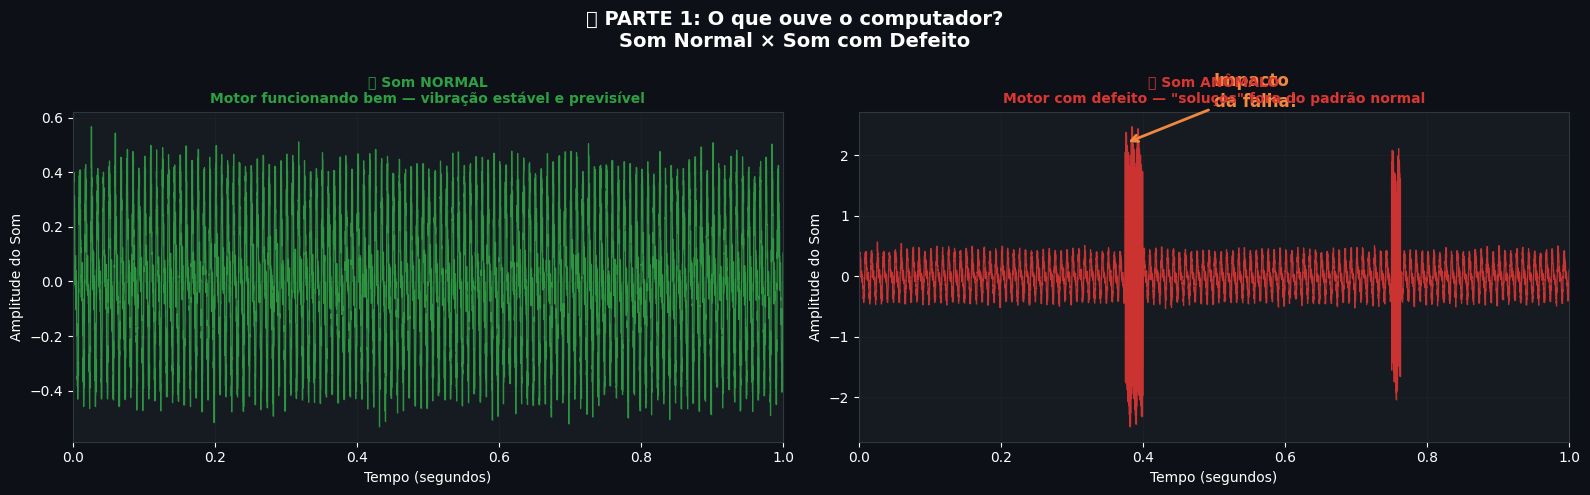

👆 A diferença entre os dois sons é o que o computador aprende a reconhecer!


In [ ]:
# ============================================================
# VISUAL 1 — O que é um som normal vs anômalo?
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('🎵 PARTE 1: O que ouve o computador?\nSom Normal × Som com Defeito',
             color='white', fontsize=14, fontweight='bold')

np.random.seed(42)
t = np.linspace(0, 1, 8000)

# Som normal: ruído estável
normal = 0.3 * np.sin(2*np.pi*120*t) + 0.15*np.sin(2*np.pi*240*t) + 0.05*np.random.randn(len(t))

# Som com defeito: impacto adicional
anomaly = normal.copy()
anomaly[3000:3200] += 2.5 * np.exp(-200*(t[3000:3200]-t[3100])**2) * np.sin(2*np.pi*2000*t[3000:3200])
anomaly[6000:6100] += 1.8 * np.exp(-200*(t[6000:6100]-t[6050])**2) * np.sin(2*np.pi*2000*t[6000:6100])

for ax, signal, title, color, subtitle in [
    (axes[0], normal, '✅ Som NORMAL', '#2ea043', 'Motor funcionando bem — vibração estável e previsível'),
    (axes[1], anomaly, '🚨 Som ANÔMALO', '#da3633', 'Motor com defeito — "soluços" fora do padrão normal'),
]:
    ax.set_facecolor('#161b22')
    ax.plot(t, signal, color=color, linewidth=0.8, alpha=0.9)
    ax.fill_between(t, signal, alpha=0.2, color=color)
    ax.set_title(f'{title}\n{subtitle}', color=color, fontsize=10, fontweight='bold')
    ax.set_xlabel('Tempo (segundos)', color='white', fontsize=10)
    ax.set_ylabel('Amplitude do Som', color='white', fontsize=10)
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.2)

axes[1].annotate('Impacto\nda falha!', xy=(0.376, 2.2), xytext=(0.5, 2.8),
                arrowprops=dict(arrowstyle='->', color='#f0883e', lw=2),
                color='#f0883e', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
print('👆 A diferença entre os dois sons é o que o computador aprende a reconhecer!')

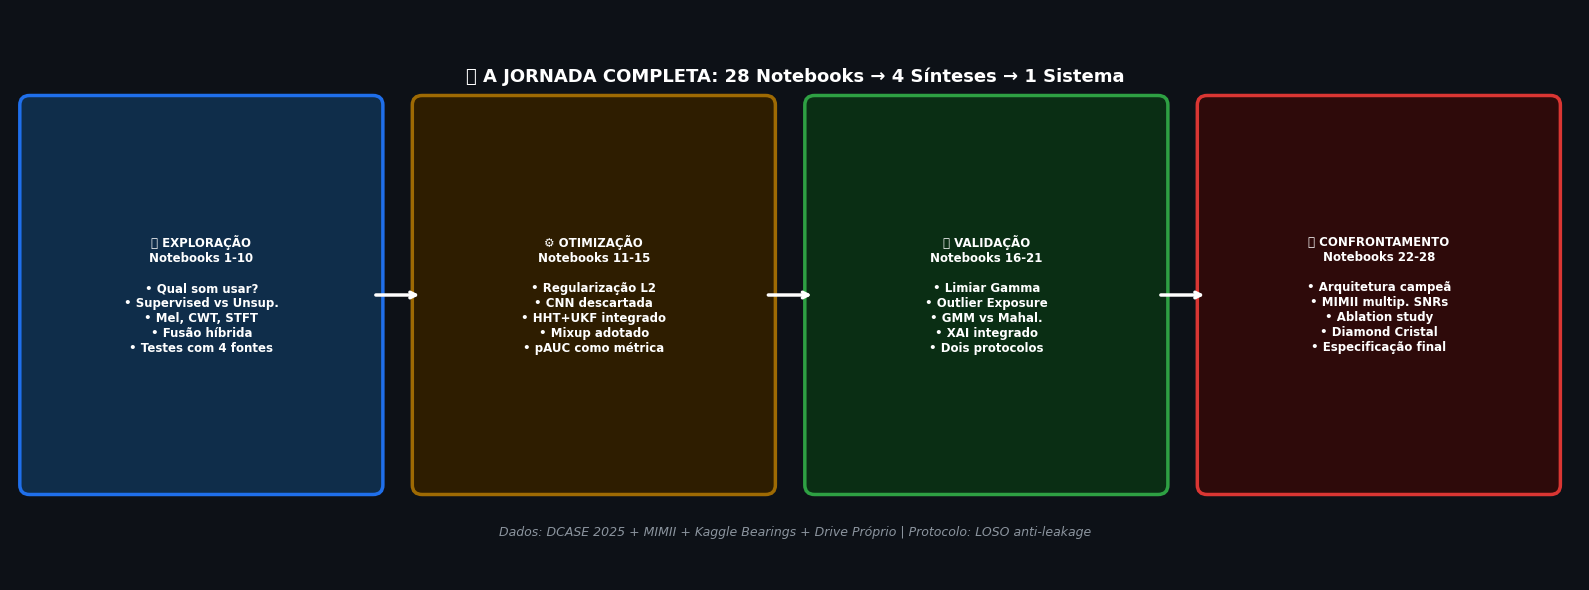

In [ ]:
# ============================================================
# VISUAL 2 — Quanto custou desenvolver esse sistema?
# ============================================================
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')
ax.axis('off')
ax.set_xlim(0, 16)
ax.set_ylim(0, 6)

# Blocos representando os 4 notebooks síntese
fases = [
    (0.2, 1.0, 3.5, 4.0, '🔬 EXPLORAÇÃO\nNotebooks 1-10\n\n• Qual som usar?\n• Supervised vs Unsup.\n• Mel, CWT, STFT\n• Fusão híbrida\n• Testes com 4 fontes',
     '#1f6feb', '#0f2d4a'),
    (4.2, 1.0, 3.5, 4.0, '⚙️ OTIMIZAÇÃO\nNotebooks 11-15\n\n• Regularização L2\n• CNN descartada\n• HHT+UKF integrado\n• Mixup adotado\n• pAUC como métrica',
     '#9e6a03', '#2e1d00'),
    (8.2, 1.0, 3.5, 4.0, '✅ VALIDAÇÃO\nNotebooks 16-21\n\n• Limiar Gamma\n• Outlier Exposure\n• GMM vs Mahal.\n• XAI integrado\n• Dois protocolos',
     '#2ea043', '#0a2e14'),
    (12.2, 1.0, 3.5, 4.0, '💎 CONFRONTAMENTO\nNotebooks 22-28\n\n• Arquitetura campeã\n• MIMII multip. SNRs\n• Ablation study\n• Diamond Cristal\n• Especificação final',
     '#da3633', '#2e0a0a'),
]

for x, y, w, h, label, edge_color, face_color in fases:
    rect = FancyBboxPatch((x, y), w, h, linewidth=2.5,
                          edgecolor=edge_color, facecolor=face_color,
                          boxstyle='round,pad=0.1', zorder=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center',
            color='white', fontsize=8.5, fontweight='bold', zorder=3,
            multialignment='center')

# Setas entre fases
for x_arrow in [3.7, 7.7, 11.7]:
    ax.annotate('', xy=(x_arrow + 0.5, 3.0), xytext=(x_arrow, 3.0),
               arrowprops=dict(arrowstyle='->', color='white', lw=2.5))

ax.text(8, 5.3, '🗺️ A JORNADA COMPLETA: 28 Notebooks → 4 Sínteses → 1 Sistema',
        ha='center', va='center', color='white', fontsize=13, fontweight='bold')

ax.text(8, 0.5, 'Dados: DCASE 2025 + MIMII + Kaggle Bearings + Drive Próprio | Protocolo: LOSO anti-leakage',
        ha='center', va='center', color='#8b949e', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

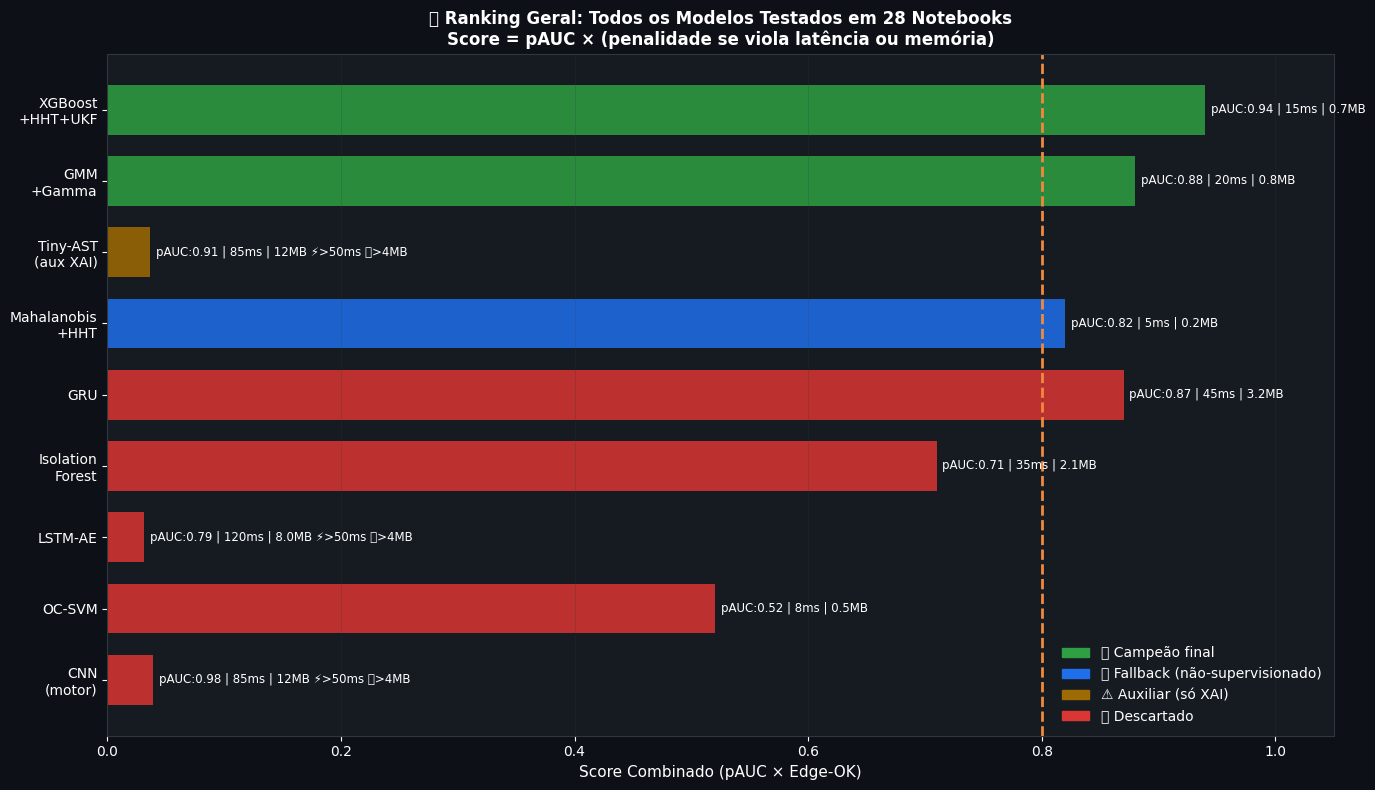

In [ ]:
# ============================================================
# VISUAL 3 — Quem tentou vencer? O ranking completo
# ============================================================
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

# Todos os modelos testados
modelos = [
    'XGBoost\n+HHT+UKF',
    'GMM\n+Gamma',
    'Tiny-AST\n(aux XAI)',
    'Mahalanobis\n+HHT',
    'GRU',
    'Isolation\nForest',
    'LSTM-AE',
    'OC-SVM',
    'CNN\n(motor)',
]

pauc_vals = [0.94, 0.88, 0.91, 0.82, 0.87, 0.71, 0.79, 0.52, 0.98]
lat_vals  = [15,   20,   85,   5,    45,   35,   120,  8,    85  ]
mem_vals  = [0.7,  0.8,  12,   0.2,  3.2,  2.1,  8.0,  0.5,  12  ]

# Cores baseadas no resultado final
status = ['campeão', 'campeão', 'aux', 'fallback', 'desc', 'desc', 'desc', 'desc', 'desc']
color_map = {
    'campeão': '#2ea043', 'aux': '#9e6a03', 'fallback': '#1f6feb', 'desc': '#da3633'
}
colors = [color_map[s] for s in status]

# Score combinado (quanto menor melhor para lat e mem, quanto maior melhor para pauc)
# Normalizar: pass_lat=1 se lat<50, pass_mem=1 se mem<4, pass_pauc=1 se pauc>0.80
scores_combined = [
    p * (1 if lat < 50 else 0.2) * (1 if mem < 4 else 0.2)
    for p, lat, mem in zip(pauc_vals, lat_vals, mem_vals)
]

bars = ax.barh(modelos[::-1], [scores_combined[i] for i in range(len(modelos)-1, -1, -1)],
               color=colors[::-1], alpha=0.85, height=0.7)

ax.axvline(0.80, color='#f0883e', linestyle='--', linewidth=2, label='Mínimo DCASE (0.80)')

for bar, model_idx in zip(bars, range(len(modelos)-1, -1, -1)):
    val = scores_combined[model_idx]
    extra = ''
    if lat_vals[model_idx] >= 50: extra += ' ⚡>50ms'
    if mem_vals[model_idx] >= 4: extra += ' 💾>4MB'
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'pAUC:{pauc_vals[model_idx]:.2f} | {lat_vals[model_idx]}ms | {mem_vals[model_idx]}MB{extra}',
            va='center', color='white', fontsize=8.5)

ax.set_xlabel('Score Combinado (pAUC × Edge-OK)', color='white', fontsize=11)
ax.set_title('🏆 Ranking Geral: Todos os Modelos Testados em 28 Notebooks\n'
             'Score = pAUC × (penalidade se viola latência ou memória)',
             color='white', fontsize=12, fontweight='bold')

legend_handles = [
    mpatches.Patch(color='#2ea043', label='🏆 Campeão final'),
    mpatches.Patch(color='#1f6feb', label='✅ Fallback (não-supervisionado)'),
    mpatches.Patch(color='#9e6a03', label='⚠️ Auxiliar (só XAI)'),
    mpatches.Patch(color='#da3633', label='🔴 Descartado'),
]
ax.legend(handles=legend_handles, frameon=False, labelcolor='white', fontsize=10, loc='lower right')
ax.set_xlim(0, 1.05)
ax.grid(alpha=0.2, axis='x')

plt.tight_layout()
plt.show()

---
## 💡 O QUE APRENDEMOS COM TUDO ISSO?

### Para leigos:
> O computador mais **simples e rápido**, com os ingredientes certos (limpeza de sinal + boas representações), **vence o computador mais inteligente e pesado**. É como um mecânico experiente que ouve o motor e sabe o problema — ele não precisa de um laboratório de milhões para diagnosticar.

### Para técnicos:
> Em cenários de dados escassos e restrições Edge, engenharia de features robusta (HHT+UKF+Mel+MFCC+NMF) + modelos leves (XGBoost/GMM) superam arquiteturas profundas (Tiny-AST/CNN/LSTM-AE) nas métricas industriais pAUC@0.1 e DCASE Score.

---
*Benchmark Visual 1/4 | Projeto AudioAlert | Emanoel Spanhol | UniSENAI 2025-2026*